Imports the required libraries


In [1]:
import keras
from keras.models import Sequential
from keras.optimizers import Adam
from keras.layers import Dense,  Activation, Conv2D, MaxPool2D, MaxPooling2D
from keras.layers import Flatten, Dropout, BatchNormalization, Reshape
# from keras.utils.vis_utils import plot_model

import os
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from mlxtend.plotting import plot_confusion_matrix
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

Stores the path of the sensor files in the corresponding list

In [2]:
""" Stores the path of the sensor files in the corresponding list """

base_path = "./data/raw/"
phone_accel_file_paths = []
watch_accel_file_paths = []

for directories, subdirectories, files in os.walk(base_path):
    for filename in files:
        if "phone" in filename and "accel" in filename:
            phone_accel_file_paths.append(f"{base_path}phone/accel/{filename}")
        elif "watch" in filename and "accel" in filename:
            watch_accel_file_paths.append(f"{base_path}watch/accel/{filename}")

Stores the actual name of each activity in the dictionary

In [3]:
""" Stores the actual name of each activity in the dictionary """

activity_dict= {"A":"Walking",
                "B":"Jogging",
                "C":"Stairs",
                "D":"Sitting",
                "E":"Standing",
                "F":"Typing",
                "G":"Brushing",
                "H":"Eat Soup",
                "I":"Eat Chips",
                "J":"Eat Pasta",
                "K":"Drinking",
                "L":"Eat Sandwich",
                "M":"Kicking",
                "O":"Playing",
                "P":"Dribblinlg",
                "Q":"Writing",
                "R":"Clapping",
                "S":"Folding"}

Removes the columns "SubjectID" and "Timestamp" from the dataframe

In [4]:
def clean_data(dataframe):
    """ Removes the columns "SubjectID" and "Timestamp" from the dataframe """
    cleaned_df = dataframe.drop(["SubjectID", "Timestamp"], axis = 1).copy()
    return cleaned_df

Normalizes the data using StandardScaler() function

In [5]:
def scale_data(data):
    """ Normalizes the data using StandardScaler() function """
    le = LabelEncoder()
    data['ActivityCode'] = le.fit_transform(data['ActivityCode'])
    X = data[['X', 'Y', 'Z']]
    y = data['ActivityCode']
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    scaled_df = pd.DataFrame(data = X, columns = ['X', 'Y', 'Z'])
    scaled_df['ActivityCode'] = y.values
    return scaled_df

Decodes the activity labels and stores them in a dictionary

In [6]:
def activity_dictionary(dataframe):
    """ Decodes the activity labels and stores them in the dictionary """
    activity_labels = dataframe["ActivityCode"]
    le = LabelEncoder()
    activity_indices = le.fit_transform(activity_labels)
    mapped_labels = dict(zip(le.transform(le.classes_), le.classes_))
    return mapped_labels

Preprocesses the data using clean() and scale() functions

In [7]:
def preprocess_data(dataframe):
    """ Preprocesses the data using clean() and scale() functions """
    cleaned_df = clean_data(dataframe)
    return scale_data(cleaned_df)

Divides data into 2D frames

In [8]:
""" Divides data into 2D frames """

frequency = 20 # Based on Hertz
time_period = 10 # Based on Second
frame_size = frequency * time_period
step_size = frame_size # In order not to have an overlap

def get_frames(df, frame_size, step_size):
    n_features = 3
    frames = []
    labels = []
    for i in range(0, len(df) - frame_size, step_size):
        x = df['X'].values[i: i + frame_size]
        y = df['Y'].values[i: i + frame_size]
        z = df['Z'].values[i: i + frame_size]
        label = stats.mode(df['ActivityCode'][i: i + frame_size])[0]
        frames.append([x, y, z])
        labels.append(label)
    frames = np.asarray(frames).reshape(-1, frame_size, n_features)
    labels = np.asarray(labels)
    return frames, labels

Builds the model (the Convolutional Neural Network)

In [9]:
def get_model():
    """ Builds the model (the Convolutional Neural Network) """
    # Defines model
    model = Sequential()
    model.add(Conv2D(64, (2, 2), activation = 'relu'))
#     model.add(Dropout(0.1))
#     model.add(Conv2D(64, (2, 2), activation='relu'))
#     model.add(Dropout(0.2))
    model.add(MaxPooling2D(pool_size=2))
    model.add(Flatten())
    model.add(Dense(128, activation = 'relu'))
    model.add(Dense(128, activation = 'relu'))
    model.add(Dropout(0.5))
    model.add(Dense(18, activation='softmax'))
    # Compiles model
    model.compile(optimizer=Adam(learning_rate = 0.001),
                  loss = 'sparse_categorical_crossentropy',
                  metrics = ['accuracy'])
    return model

Phone Accelerometer

In [10]:
""" Phone Accelerometer """

data = pd.concat([pd.read_csv(file,  names=['SubjectID','ActivityCode','Timestamp','X','Y','Z'], header=None) for file in phone_accel_file_paths])

activity_labels = list(activity_dictionary(data).values())
processed_data = preprocess_data(data)

X, y = get_frames(processed_data, frame_size, step_size)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 3, 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 3, 1)

model = get_model()
history = model.fit(X_train, y_train, batch_size=4, epochs=70, verbose=1)

scores = model.evaluate(X_test, y_test, verbose=0)

y_true = y_test
predict_x=model.predict(X_test)
y_pred=np.argmax(predict_x,axis=-1)


Epoch 1/70
4805/4805 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - accuracy: 0.1989 - loss: 2.3494
Epoch 2/70
4805/4805 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.2939 - loss: 1.9711
Epoch 3/70
4805/4805 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.3366 - loss: 1.8343
Epoch 4/70
4805/4805 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.3618 - loss: 1.7668
Epoch 5/70
4805/4805 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.3935 - loss: 1.6915
Epoch 6/70
4805/4805 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.4189 - loss: 1.6403
Epoch 7/70
4805/4805 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.4381 - loss: 1.5725
Epoch 8/70
4805/4805 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.4358 - loss: 1.5612
Epoch 9/70
4805/4805 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.4640 - loss: 1.4971
Epoch 10/70
4805/4805 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.4683 - loss: 1.4857
Epoch 11/70
4805/4805 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.4759 - loss: 1.4566
Epoch 12/70
4805/48

Performance metrics

Precision: [0.69615385 0.87719298 0.50929368 0.54245283 0.44791667 0.38515901
 0.5093633  0.37662338 0.47668394 0.40092166 0.33165829 0.38194444
 0.50655022 0.37974684 0.43478261 0.51086957 0.42790698 0.45704467]
Recall: [0.64642857 0.93283582 0.53515625 0.43560606 0.63703704 0.44129555
 0.5037037  0.21402214 0.35249042 0.348      0.46315789 0.20676692
 0.41577061 0.33210332 0.58394161 0.36153846 0.68656716 0.50188679]
F1 Score: [0.67037037 0.90415913 0.52190476 0.48319328 0.52599388 0.41132075
 0.50651769 0.27294118 0.40528634 0.37259101 0.38653001 0.26829268
 0.45669291 0.35433071 0.49844237 0.42342342 0.52722063 0.47841727]


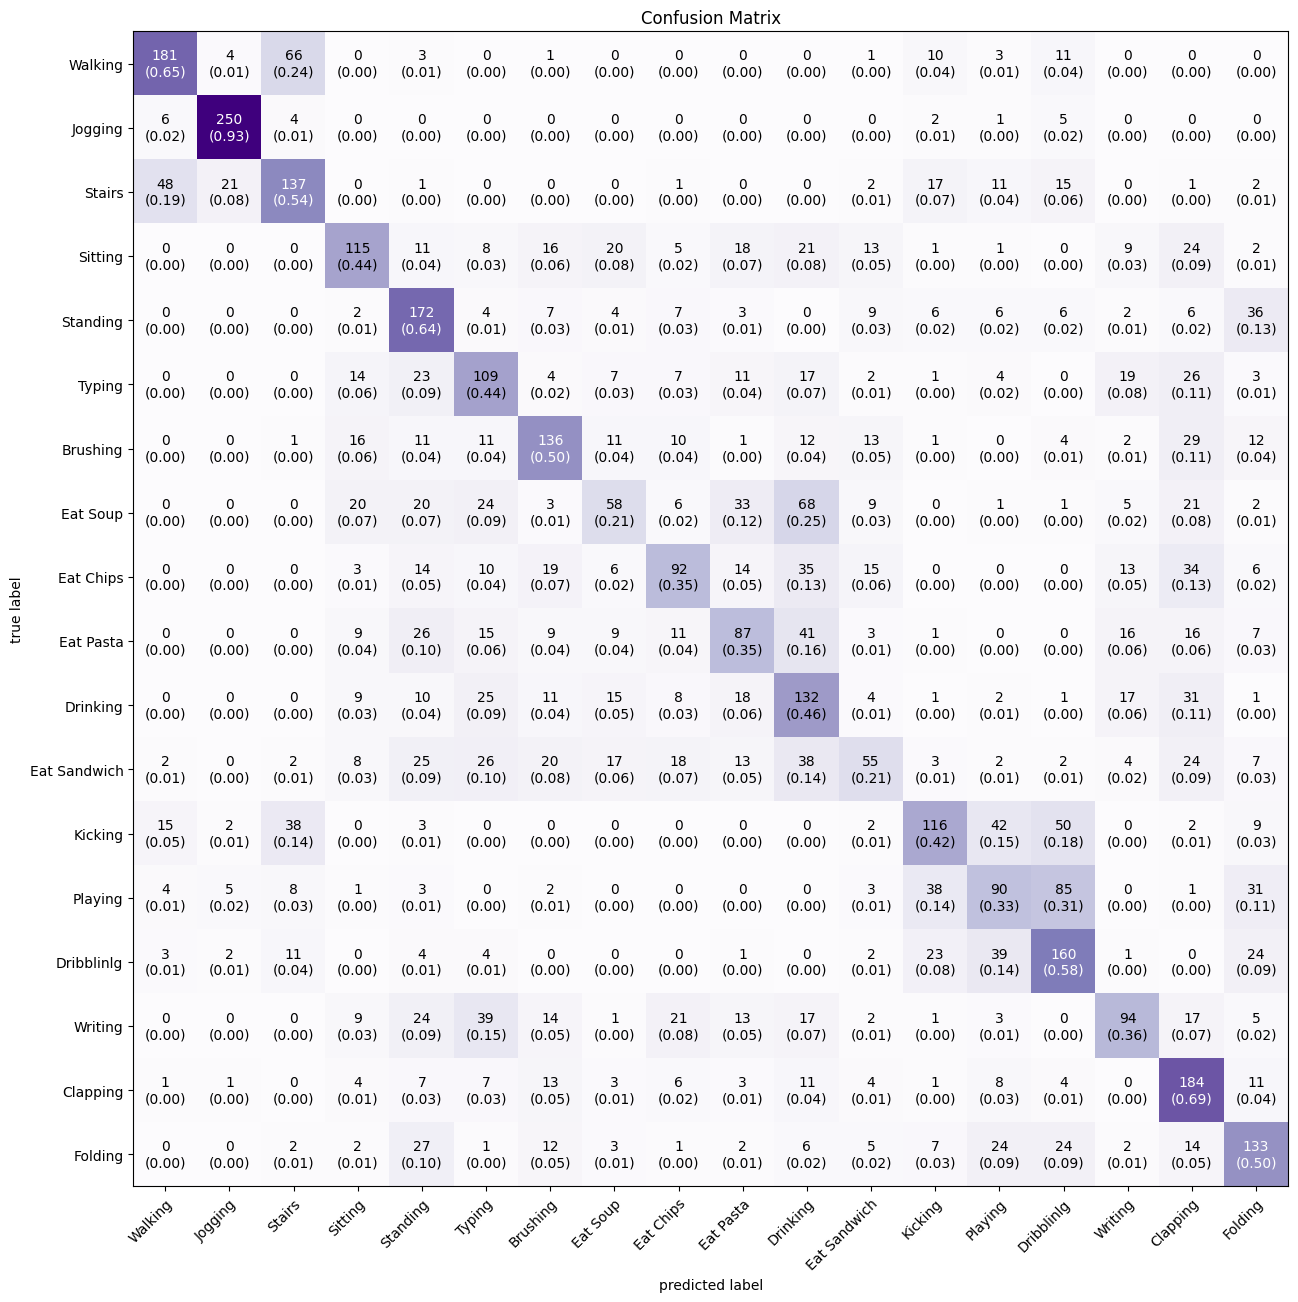

In [12]:


    # Accuracy: (tp + tn) / (p + n)
phone_accel_accuracy = accuracy_score(y_true, y_pred)

    # Precision tp / (tp + fp)
phone_accel_precision = precision_score(y_true, y_pred, average=None, zero_division=1)

    # Recall: tp / (tp + fn)
phone_accel_recall = recall_score(y_true, y_pred, average=None, zero_division=1)

    # F1: 2 tp / (2 tp + fp + fn)
phone_accel_f1 = f1_score(y_true, y_pred, average=None, zero_division=1)

phone_accel_classification_reports = classification_report(y_true, y_pred, zero_division=1)

    # matrix = confusion_matrix(y_test, y_pred)
phone_accel_confusion_matrix = confusion_matrix(y_true, y_pred)

accu_per_class = phone_accel_confusion_matrix.diagonal()/ phone_accel_confusion_matrix.sum(axis=1)
phone_accel_activity_accuracy = dict(zip(activity_labels, accu_per_class))

print(f'Precision: {phone_accel_precision}')
print(f'Recall: {phone_accel_recall}')
print(f'F1 Score: {phone_accel_f1}')
# print(f'Confison Matrix:\n {phone_accel_confusion_matrix}')
plot_confusion_matrix(conf_mat = phone_accel_confusion_matrix, class_names=activity_dict.values(), show_normed=True, figsize=(15,15), cmap=plt.cm.Purples)
plt.title('Confusion Matrix')
plt.show()
